In [1]:
# features = rainfall_gdf_merged[["mean_dem", "mean_slope"]]
# scaler = StandardScaler()
# X = scaler.fit_transform(features)

# for k in range(2, 10):
#     km = KMeans(n_clusters=k, random_state=0)
#     labels_A = km.fit_predict(X)
#     #print(k, silhouette_score(X, labels_A))


# # --------
# features_more = rainfall_gdf_merged[["mean_dem", "mean_slope", "std_dem", "std_slope"]]
# scaler = StandardScaler()
# X = scaler.fit_transform(features_more)

# for k in range(2, 10):
#     km = KMeans(n_clusters=k, random_state=0)
#     labels_B = km.fit_predict(X)
#     #print(k, silhouette_score(X, labels_B))




In [2]:
# # ------
# k = 6  # start here

# features = rainfall_gdf_merged[["mean_dem", "mean_slope"]]
# scaler = StandardScaler()
# X = scaler.fit_transform(features)

# kmeans = KMeans(n_clusters=k, random_state=0)
# labels_B = kmeans.fit_predict(X)

# # Attach labels back to data
# rainfall_gdf_merged["cluster_B"] = labels_B

# rainfall_gdf_merged.groupby("cluster")[["std_dem", "std_slope"]].mean()

In [3]:
# # ------

# features_more = rainfall_gdf_merged[["mean_dem", "mean_slope", "std_dem", "std_slope"]]
# scaler = StandardScaler()
# X = scaler.fit_transform(features_more)

# kmeans = KMeans(n_clusters=k, random_state=0)
# labels_A = kmeans.fit_predict(X)

# # Attach labels back to data
# rainfall_gdf_merged["cluster_B"] = labels_A

# rainfall_gdf_merged.groupby("cluster")[["std_dem", "std_slope"]].mean()

In [4]:
# from sklearn.metrics import adjusted_rand_score

# ari = adjusted_rand_score(labels_A, labels_B)
# print("ARI:", ari)

<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [12]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib    
import seaborn as sns
from sklearn.decomposition import PCA

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

import functions
importlib.reload(functions)
from functions import *

### Get rain gauge data

In [6]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700")

### Get gridded rainfall data

In [7]:
rainfall_gdf_merged = gpd.read_file(data_dir+ "Derived/rainfall_gdf_merged.gpkg")

In [8]:
cell_centroids = rainfall_gdf_merged.geometry.centroid

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Implement a cluster analysis </h3>
    
This is designed to find the best way to partition the 1km grid cells into groups which have similar environmental characteristics.    
    
 - Define the optimal number of clusters using silhouette scores
 - Run the cluster analysis
    
  </div>    
</div>

#### Define optimal cluster number

In [9]:
# plt.scatter(rainfall_gdf_merged['mean_dem'], rainfall_gdf_merged['std_dem'])
# plt.scatter(rainfall_gdf_merged['mean_slope'], rainfall_gdf_merged['std_slope'])

In [10]:
def plot_and_check(rainfall_gdf_merged, solution,cell_centroids, catchment_Dolwen, existing_coords,min_dist,title, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # --------------------------------------------------            
    catchment_Dolwen.boundary.plot(ax=ax, color="black")     
    rainfall_gdf_merged.plot(column="cluster",categorical=True,legend=True,ax=ax,alpha=1 , cmap='Set1')
    rainfall_gdf_merged.boundary.plot(ax=ax, color="black", linewidth=1) # Grid outlines        
        
    # --------------------------------------------------
    # Extract selected points
    # --------------------------------------------------
    selected_idx = list(solution.values())

    selected_coords = np.vstack([np.array([cell_centroids[i].x, cell_centroids[i].y])
        for i in selected_idx])
    
    existing_coords = np.asarray(existing_coords)

    # --------------------------------------------------
    # Plot base data (optional but useful)
    # --------------------------------------------------
    ax.scatter(existing_coords[:, 0], existing_coords[:, 1], c="red", marker = "X", label="Existing gauges", s=60)
    ax.scatter(selected_coords[:, 0], selected_coords[:, 1], c="black", label="Selected new gauges", s=40)

    # --------------------------------------------------
    # Draw buffer circles (true constraint radius)
    # --------------------------------------------------
    for x, y in selected_coords:
        circle = plt.Circle((x, y), min_dist, fill=False, linestyle="--", color="red", alpha=1)
        ax.add_patch(circle)

    # --------------------------------------------------
    # Final plot formatting
    # --------------------------------------------------
    ax.set_title(title)
    #ax.legend()
    ax.set_aspect("equal")

    # plt.show()
    
    
def plot_with_rainfall(rainfall_gdf_merged, solution,cell_centroids, catchment_Dolwen, existing_coords,min_dist,title, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # --------------------------------------------------            
    catchment_Dolwen.boundary.plot(ax=ax, color="black")     
    rainfall_gdf_merged.plot(column="mean_daily_rainfall",categorical=True,ax=ax,alpha=1 , cmap='Blues')
    rainfall_gdf_merged.boundary.plot(ax=ax, color="black", linewidth=1) # Grid outlines        
        
    # --------------------------------------------------
    # Extract selected points
    # --------------------------------------------------
    selected_idx = list(solution.values())

    selected_coords = np.vstack([np.array([cell_centroids[i].x, cell_centroids[i].y])
        for i in selected_idx])
    
    existing_coords = np.asarray(existing_coords)

    # --------------------------------------------------
    # Plot base data (optional but useful)
    # --------------------------------------------------
    ax.scatter(existing_coords[:, 0], existing_coords[:, 1], c="red", marker = "X", label="Existing gauges", s=60)
    ax.scatter(selected_coords[:, 0], selected_coords[:, 1], c="black", label="Selected new gauges", s=40)

    # --------------------------------------------------
    # Draw buffer circles (true constraint radius)
    # --------------------------------------------------
    for x, y in selected_coords:
        circle = plt.Circle((x, y), min_dist, fill=False, linestyle="--", color="red", alpha=1)
        ax.add_patch(circle)

    # --------------------------------------------------
    # Final plot formatting
    # --------------------------------------------------
    ax.set_title(title)
    #ax.legend()
    ax.set_aspect("equal")

    # plt.show()    

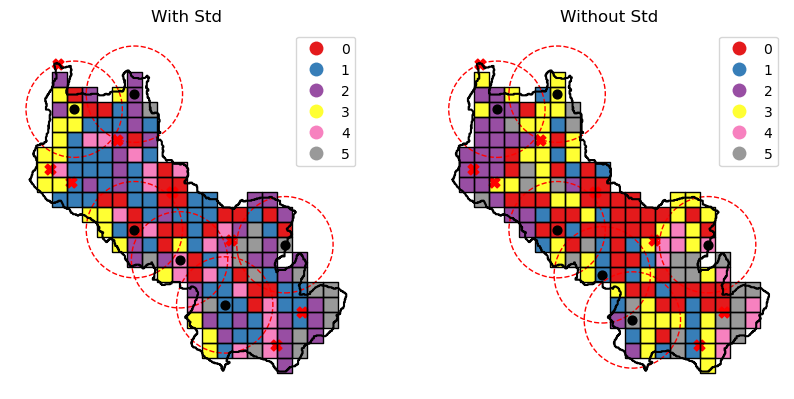

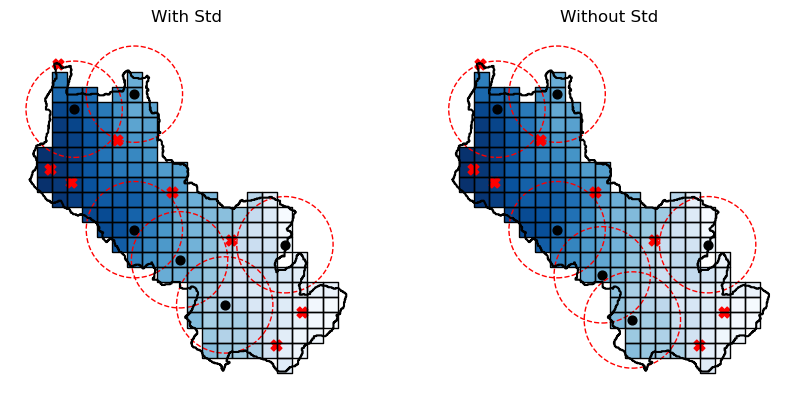

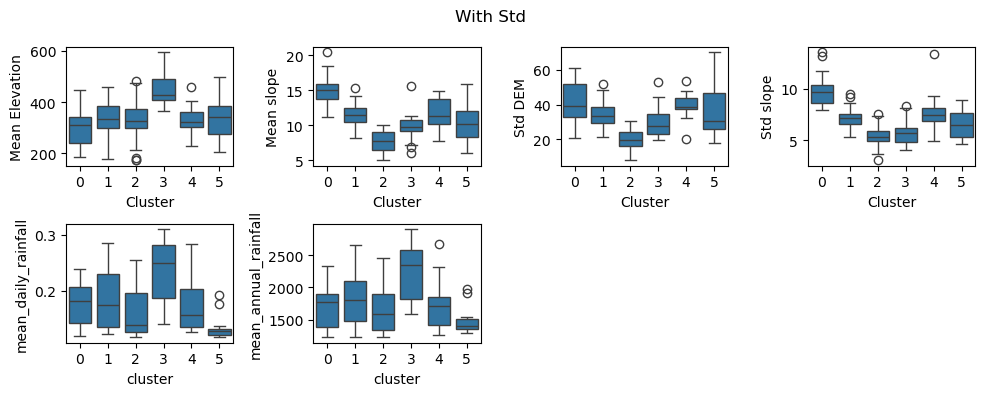

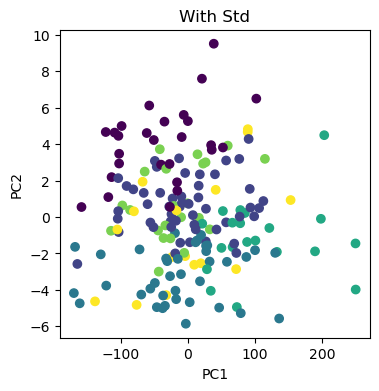

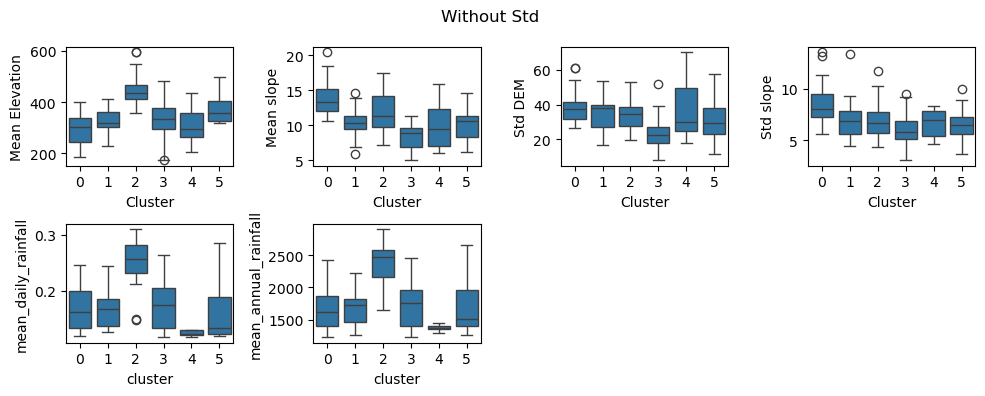

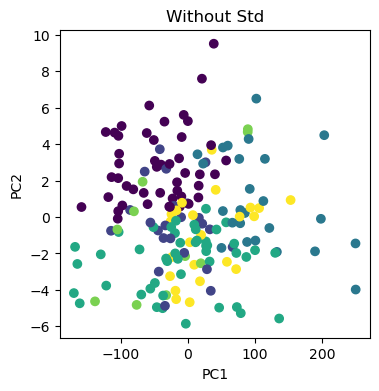

In [17]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


def run_cluster(features_ls, name, min_dist, ax1, ax2 ):
    features = rainfall_gdf_merged[features_ls]
                                        # "x_coord", "y_coord"]]
    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    k = 6  # start here
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)

    # Attach labels back to data
    rainfall_gdf_merged["cluster"] = labels

    existing_gauges = rain_meta_sf.to_crs(rainfall_gdf_merged.crs)
    existing_coords = np.array([(g.x, g.y) for g in existing_gauges.geometry])
    existing_coords = np.asarray(existing_coords)

    cell_coords = np.array([(geom.x, geom.y) for geom in cell_centroids.geometry])

    # ------------------------------------ #
    # For each of the clusters, find a list of the cells which 
    # would best represent the cluster, in order of appropriateness
    # This is based on: how close each grid cell is to the cluster centroid (in feature space)
    # ------------------------------------ #
    cluster_candidates = {}

    # Loop through each grid cell (and the cluster label assigned to it)
    for c in np.unique(labels):
        cluster_idx = np.where(labels == c)[0]
        cluster_points = X[cluster_idx]

        centroid = kmeans.cluster_centers_[c]

        # distances to centroid
        distances = np.linalg.norm(cluster_points - centroid, axis=1)

        # sort candidates (best first)
        sorted_idx = cluster_idx[np.argsort(distances)]

        cluster_candidates[c] = sorted_idx

    # --------------------------------------------------
    # 1. RUN SINGLE GREEDY (baseline / fixed order)
    # --------------------------------------------------
    greedy_solution, greedy_failed = greedy_selection(cluster_candidates,cell_coords,existing_coords,min_dist)

    # evaluate greedy result
    res_greedy = evaluate_solution(greedy_solution,cluster_candidates,cell_coords,existing_coords,min_dist)

    # --------------------------------------------------
    # 2. RUN SHUFFLE + GREEDY (ensemble search)
    # --------------------------------------------------
    shuffle_solution = shuffle_greedy(cluster_candidates,cell_coords,existing_coords,min_dist,n_iterations=500)

    # evaluate best shuffled solution
    res_shuffle = evaluate_solution(shuffle_solution,cluster_candidates,cell_coords,existing_coords,min_dist)


    #print("\n--- SHUFFLE GREEDY ---")
    plot_and_check(rainfall_gdf_merged, shuffle_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 
                   name, ax=ax1)
    ax1.axis('off')
    
    plot_with_rainfall(rainfall_gdf_merged, shuffle_solution, cell_centroids, catchment_Dolwen, existing_coords, min_dist, 
                   name, ax=ax2)
    ax2.axis('off')
    
    fig,axs=plt.subplots(ncols=4, nrows =2, figsize=(10,4))
    axs=axs.flatten()
    sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_dem'], ax=axs[0])
    axs[0].set_xlabel("Cluster")
    axs[0].set_ylabel("Mean Elevation")
    #axs[0].set_title("Distribution of Elevation by Cluster");

    sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_slope'], ax=axs[1])
    axs[1].set_xlabel("Cluster")
    axs[1].set_ylabel("Mean slope")
    #axs[1].set_title("Distribution of Slope by Cluster");


    sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['std_dem'], ax=axs[2])
    axs[2].set_xlabel("Cluster")
    axs[2].set_ylabel("Std DEM")
    #axs[3].set_title("Distribution of Max elevation by Cluster");    
    
    sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['std_slope'], ax=axs[3])
    axs[3].set_xlabel("Cluster")
    axs[3].set_ylabel("Std slope")
    #axs[3].set_title("Distribution of Max elevation by Cluster");    
    
    sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_daily_rainfall'], ax=axs[4])
    axs[3].set_xlabel("Cluster")
    axs[3].set_ylabel("Std slope")
    #axs[3].set_title("Distribution of Max elevation by Cluster");  
    
    sns.boxplot(x=rainfall_gdf_merged['cluster'],y=rainfall_gdf_merged['mean_annual_rainfall'], ax=axs[5])
    axs[3].set_xlabel("Cluster")
    axs[3].set_ylabel("Std slope")
    #axs[3].set_title("Distribution of Max elevation by Cluster");        
    
    N = 6  # number of plots you actually filled

    for i in range(N, len(axs)):
        axs[i].set_visible(False)

    fig.suptitle(f"{name}")
    fig.tight_layout()

    X = rainfall_gdf_merged[["mean_dem", "mean_slope", "aspect_sin", "aspect_cos"]]

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    fig,ax=plt.subplots(figsize=(4,4))
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=rainfall_gdf_merged["cluster"])
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{name}")

fig1,axs1 =plt.subplots(ncols=2, figsize=(10,10))
fig2,axs2 =plt.subplots(ncols=2, figsize=(10,10))
run_cluster(["mean_dem", "mean_slope", "aspect_sin","aspect_cos",'std_slope', 'std_dem'], 'With Std', 3200, axs1[0], axs2[0])
run_cluster(["mean_dem", "mean_slope", "aspect_sin","aspect_cos",], 'Without Std', 3200, axs1[1], axs2[1])